# Balanced Exponential Reweighting — Schäfer & Settanni (2020)

**Method**: Equations 14–16 from *Data Reweighting in Metadynamics Simulations* (JCTC 2020, 16, 2042–2052).

The balanced exponential weight for frame $i$ at time $t$ is:

$$w_i^{\mathrm{bex}} = \exp\!\bigl[\beta\,(V(\mathbf{s}(\mathbf{r}_i), t) - V_a(t))\bigr]$$

where $V_a(t) = \langle V(\mathbf{s}, t) \rangle_{\mathbf{s}}$ is the **spatial average** of the accumulated bias potential over CV space at time $t$.

$V_a(t)$ is computed from the HILLS file: each deposited Gaussian is analytically integrated over the CV domain $[\mathbf{s}_{\min}, \mathbf{s}_{\max}]$ and divided by the domain volume.

**298 K, 0.5 M | 10 replicas × 10 skip-frame estimates**

In [1]:
import sys, os, pickle, warnings, glob, importlib
warnings.filterwarnings('ignore')
sys.path.append('/expanse/lustre/projects/csd799/xiruan/scripts/solvation_scripts/python')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erf

import free_energy_tool
importlib.reload(free_energy_tool)
from free_energy_tool import ClusterAnalyzer, EnergyCorrectionAnalyzer

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_PATH  = '/expanse/lustre/projects/csd799/xiruan/2026/solvation_revision/298K/0.5M/reweighting_time_depend/298K_0.5M_data/0.5M'
OUT_PATH   = '/expanse/lustre/projects/csd799/xiruan/2026/solvation_revision/298K/0.5M/reweighting_time_depend/results_balanced_exp_reweight'
META2_PATH = '/expanse/lustre/projects/csd799/xiruan/solvation_298K/meta_single_Li/0.5M/meta2'

# ── Simulation parameters ──────────────────────────────────────────────────
T            = 298
CONC         = 0.5
NSTRIDES     = 10
N_REPLICAS   = 10
LI_INDEX     = 2946
LI_ID        = LI_INDEX + 1

TIMESTEP_FS  = 1.0
NS_TO_STEPS  = int(1e6 / TIMESTEP_FS)

# ── Time window selection ──────────────────────────────────────────────────
# Set EQUIL_NS > 0 to discard early frames (e.g. 2.0 to skip first 2 ns)
# Set MAX_NS = None to keep all frames, or a value to truncate
EQUIL_NS     = 0.0                                  # <-- change to 2.0 to discard first 2 ns
MAX_NS       = None                                  # <-- change to e.g. 20.0 to stop at 20 ns
EQUIL_STEPS  = int(EQUIL_NS * NS_TO_STEPS)
MAX_STEPS    = int(MAX_NS * NS_TO_STEPS) if MAX_NS is not None else None

WINDOW_NS    = 2.0
WINDOW_STEPS = int(WINDOW_NS * NS_TO_STEPS)

N_SKIPS      = 10

kB           = 1.987204e-3  # kcal/(mol·K)
beta         = 1.0 / (kB * T)

# CV domain boundaries for spatial averaging of Gaussians
CV_LOWER = np.array([0.0, 0.0, 0.0])
CV_UPPER = np.array([7.0, 7.0, 7.0])

os.makedirs(OUT_PATH, exist_ok=True)
print(f'Output → {OUT_PATH}')
print(f'β = {beta:.4f} (mol/kcal)  |  T = {T} K')
print(f'CV domain: {CV_LOWER} → {CV_UPPER}')
print(f'Time window: [{EQUIL_NS} ns, {MAX_NS if MAX_NS else "end"}]  '
      f'→ steps [{EQUIL_STEPS}, {MAX_STEPS if MAX_STEPS else "all"}]')

Output → /expanse/lustre/projects/csd799/xiruan/2026/solvation_revision/298K/0.5M/reweighting_time_depend/results_balanced_exp_reweight
β = 1.6887 (mol/kcal)  |  T = 298 K
CV domain: [0. 0. 0.] → [7. 7. 7.]
Time window: [0.0 ns, end]  → steps [0, all]


## 1. Read HILLS files and compute $V_a(t)$ from spatial averaging

For each Gaussian hill deposited at time $t'$ with center $\mathbf{c}$, width $\boldsymbol{\sigma}$, and height $W$:

$$\langle g_{t'} \rangle_{\mathbf{s}} = \frac{1}{\mathrm{Vol}} \int_{\mathbf{s}_{\min}}^{\mathbf{s}_{\max}} W \prod_i \exp\!\left(-\frac{(s_i - c_i)^2}{2\sigma_i^2}\right) d\mathbf{s}
= \frac{W}{\mathrm{Vol}} \prod_i \sigma_i \sqrt{2\pi}\left[\Phi\!\left(\frac{s_{\max,i} - c_i}{\sigma_i}\right) - \Phi\!\left(\frac{s_{\min,i} - c_i}{\sigma_i}\right)\right]$$

Then $V_a(t) = \sum_{t' \le t} \langle g_{t'} \rangle_{\mathbf{s}}$ (cumulative sum of spatial averages).

In [ ]:
def read_hills_file(filepath):
    """Read a colvars .hills.traj file.
    Columns: step, cv1, cv2, cv3, sigma1, sigma2, sigma3, height
    """
    return pd.read_csv(
        filepath, sep=r"\s+", header=None,
        names=["step", "cv1", "cv2", "cv3", "sigma1", "sigma2", "sigma3", "height"],
    )


def gaussian_spatial_average(centers, sigmas, height, lower, upper):
    """Analytical spatial average of a multidimensional Gaussian over a box.

    Returns <g>_s = (1/Vol) * integral of W * prod_i exp(-(s_i-c_i)^2/(2*sigma_i^2)) ds
    """
    volume = np.prod(upper - lower)
    integral_per_dim = sigmas * np.sqrt(2 * np.pi) * 0.5 * (
        erf((upper - centers) / (sigmas * np.sqrt(2)))
        - erf((lower - centers) / (sigmas * np.sqrt(2)))
    )
    return height * np.prod(integral_per_dim) / volume


def compute_Va_from_hills(hills_df, lower, upper):
    """Compute cumulative spatial average V_a(t) for each hill deposition time.

    For multiple-walker MTD: all replicas deposit hills into a shared bias,
    so we pool all replicas' hills, sort by step, and compute the cumulative
    spatial average.

    Parameters
    ----------
    hills_df : DataFrame
        Columns: step, cv1, cv2, cv3, sigma1, sigma2, sigma3, height
    lower, upper : array-like, shape (n_cv,)
        CV domain boundaries.

    Returns
    -------
    DataFrame with columns: step, spatial_avg, Va (cumulative sum)
    """
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)

    centers = hills_df[["cv1", "cv2", "cv3"]].values
    sigmas  = hills_df[["sigma1", "sigma2", "sigma3"]].values
    heights = hills_df["height"].values

    spatial_avgs = np.array([
        gaussian_spatial_average(centers[i], sigmas[i], heights[i], lower, upper)
        for i in range(len(hills_df))
    ])

    result = hills_df[["step"]].copy()
    result["spatial_avg"] = spatial_avgs
    result = result.sort_values("step").reset_index(drop=True)
    result["Va"] = result["spatial_avg"].cumsum()
    return result

In [4]:
# Read HILLS per replica (each replica has its own independent bias)
# Build per-replica V_a(t) lookup tables
va_tables_per_replica = {}

for i in range(1, N_REPLICAS + 1):
    pattern = os.path.join(META2_PATH, f"{i:02d}_IDNR", "colvar.out.colvars.metadyn_d*.*.hills.traj")
    files = sorted(glob.glob(pattern))
    rep_hills_frames = []
    for f in files:
        df = read_hills_file(f)
        rep_hills_frames.append(df)

    rep_hills = pd.concat(rep_hills_frames, ignore_index=True)
    hills_va = compute_Va_from_hills(rep_hills, lower=CV_LOWER, upper=CV_UPPER)

    # Build step → V_a lookup for this replica
    # Prepend step=0 with Va=0 (no bias before the first hill deposition)
    va_by_step = hills_va.groupby("step")["Va"].last()
    va_dict = {0: 0.0}
    va_dict.update(zip(va_by_step.index.astype(int), va_by_step.values))
    va_tables_per_replica[i] = va_dict

    print(f"  Replica {i:02d}: {len(rep_hills):,} hills → {len(va_tables_per_replica[i]):,} unique steps  "
          f"V_a range: [0, {hills_va['Va'].max():.4f}] kcal/mol")

print(f"\nBuilt V_a tables for {len(va_tables_per_replica)} replicas")

  Replica 01: 26,772 hills → 26,773 unique steps  V_a range: [0, 0.1739] kcal/mol
  Replica 02: 26,254 hills → 26,255 unique steps  V_a range: [0, 0.1693] kcal/mol
  Replica 03: 22,306 hills → 22,307 unique steps  V_a range: [0, 0.1479] kcal/mol
  Replica 04: 23,283 hills → 23,284 unique steps  V_a range: [0, 0.1535] kcal/mol
  Replica 05: 24,886 hills → 24,887 unique steps  V_a range: [0, 0.1588] kcal/mol
  Replica 06: 23,051 hills → 23,052 unique steps  V_a range: [0, 0.1524] kcal/mol
  Replica 07: 24,267 hills → 24,268 unique steps  V_a range: [0, 0.1558] kcal/mol
  Replica 08: 24,786 hills → 24,787 unique steps  V_a range: [0, 0.1593] kcal/mol
  Replica 09: 26,000 hills → 26,001 unique steps  V_a range: [0, 0.1699] kcal/mol
  Replica 10: 22,379 hills → 22,380 unique steps  V_a range: [0, 0.1500] kcal/mol

Built V_a tables for 10 replicas


In [5]:
# Save per-replica V_a tables for reference
for rep_id, va_dict in va_tables_per_replica.items():
    va_df = pd.DataFrame(sorted(va_dict.items()), columns=["step", "Va"])
    va_df.to_csv(os.path.join(OUT_PATH, f"va_table_replica_{rep_id:02d}.csv"), index=False)

print(f"Saved {len(va_tables_per_replica)} per-replica V_a tables to {OUT_PATH}")

Saved 10 per-replica V_a tables to /expanse/lustre/projects/csd799/xiruan/2026/solvation_revision/298K/0.5M/reweighting_time_depend/results_balanced_exp_reweight


In [6]:
# Quick sanity check: compare V_a(t) across replicas at a few time points
check_steps = [0, 1000, 10000, 100000, 1000000, 10000000, 26000000]
print("V_a(t) comparison across replicas:")
print(f"{'Step':>12s}", end="")
for r in range(1, N_REPLICAS + 1):
    print(f"  {'Rep'+str(r):>8s}", end="")
print()
for step in check_steps:
    print(f"{step:>12d}", end="")
    for r in range(1, N_REPLICAS + 1):
        va_dict = va_tables_per_replica[r]
        va_steps = sorted(va_dict.keys())
        va_arr = np.array(va_steps, dtype=np.int64)
        idx = np.searchsorted(va_arr, step, side="right") - 1
        val = va_dict[int(va_arr[max(idx, 0)])] if idx >= 0 else 0.0
        print(f"  {val:>8.4f}", end="")
    print()

V_a(t) comparison across replicas:
        Step      Rep1      Rep2      Rep3      Rep4      Rep5      Rep6      Rep7      Rep8      Rep9     Rep10
           0    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000
        1000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000
       10000    0.0001    0.0000    0.0000    0.0000    0.0000    0.0001    0.0000    0.0000    0.0000    0.0001
      100000    0.0005    0.0005    0.0004    0.0005    0.0005    0.0006    0.0004    0.0005    0.0002    0.0006
     1000000    0.0061    0.0065    0.0063    0.0064    0.0059    0.0066    0.0064    0.0064    0.0057    0.0066
    10000000    0.0611    0.0646    0.0656    0.0652    0.0617    0.0669    0.0666    0.0632    0.0645    0.0668
    26000000    0.1687    0.1679    0.1479    0.1535    0.1588    0.1524    0.1558    0.1593    0.1699    0.1500


## 2. Read COLVAR trajectories and attach $V_a(t)$

Each colvar frame has `E_metadyn_d1` = $V(\mathbf{s}(\mathbf{r}),t)$, the instantaneous bias at that configuration.

We attach $V_a(t)$ (from the HILLS spatial averaging) using nearest-earlier-step lookup, then compute:
- $V_{\mathrm{corr},i} = V_i - V_a(t_i)$
- $w_i = \exp(\beta \cdot V_{\mathrm{corr},i})$

In [7]:
def attach_Va_to_colvar(colvar_df, va_table_dict, step_col="step"):
    """Attach V_a(t) to each colvar frame using nearest-earlier-step lookup."""
    va_steps = np.array(sorted(va_table_dict.keys()), dtype=np.int64)
    va_vals  = np.array([va_table_dict[s] for s in va_steps])

    steps = colvar_df[step_col].values.astype(np.int64)
    idx = np.searchsorted(va_steps, steps, side="right") - 1
    idx = np.clip(idx, 0, len(va_steps) - 1)

    result = colvar_df.copy()
    result["Va"] = va_vals[idx]
    return result


def compute_reweighting_weights(colvar_df, bias_col="E_metadyn_d1", temperature=298.0, normalize=True):
    """Compute balanced exponential reweighting weights: w_i = exp(β*(V_i - V_a(t_i)))."""
    kB_local = 1.987204e-3
    beta_local = 1.0 / (kB_local * temperature)

    result = colvar_df.copy()
    result["V_corr"] = result[bias_col] - result["Va"]
    result["log_weight"] = beta_local * result["V_corr"]
    max_lw = result["log_weight"].max()
    result["weight"] = np.exp(result["log_weight"] - max_lw)
    if normalize:
        result["weight"] /= result["weight"].sum()
    return result


# Quick demo: read replica 01's colvar, attach its own V_a, compute weights
colvar_cols = ["step", "coord_Li_O", "coord_Li_Cl", "coord_Li", "E_metadyn_d1"]
demo_colvar = pd.read_csv(
    os.path.join(META2_PATH, "01_IDNR", "colvar.out.colvars.traj"),
    sep=r"\s+", comment="#", header=None, names=colvar_cols,
)
demo_colvar = demo_colvar.dropna(subset=["E_metadyn_d1"])

demo_with_va = attach_Va_to_colvar(demo_colvar, va_tables_per_replica[1])
demo_weighted = compute_reweighting_weights(demo_with_va, temperature=T)

print("Demo (replica 01, using its own V_a):")
print(demo_weighted[["step", "coord_Li_O", "coord_Li_Cl", "coord_Li", "E_metadyn_d1", "Va", "V_corr", "weight"]].head(10))
print(f"\n... {len(demo_weighted):,} frames total")

Demo (replica 01, using its own V_a):
   step  coord_Li_O  coord_Li_Cl  coord_Li  E_metadyn_d1   Va  V_corr  \
0     0    4.990668     0.083435  0.311228           0.0  0.0     0.0   
1   100    4.964872     0.053024  0.307121           0.0  0.0     0.0   
2   200    4.904903     0.090440  0.405425           0.0  0.0     0.0   
3   300    4.887151     0.140151  0.426982           0.0  0.0     0.0   
4   400    4.786963     0.156160  0.440159           0.0  0.0     0.0   
5   500    4.793946     0.153855  0.548775           0.0  0.0     0.0   
6   600    4.823749     0.101432  0.524801           0.0  0.0     0.0   
7   700    4.922902     0.074410  0.475880           0.0  0.0     0.0   
8   800    4.959176     0.065243  0.459092           0.0  0.0     0.0   
9   900    4.957903     0.086981  0.520811           0.0  0.0     0.0   

         weight  
0  1.688581e-20  
1  1.688581e-20  
2  1.688581e-20  
3  1.688581e-20  
4  1.688581e-20  
5  1.688581e-20  
6  1.688581e-20  
7  1.688581e-2

## 3. Load x_free_water and set up EnergyCorrectionAnalyzer

In [8]:
# Load x_free_water from SKIP_0 (identical across all skips — same trajectory)
x_free_water = None
for skip in range(N_SKIPS):
    xfw_path = os.path.join(DATA_PATH, f'SKIP_{skip}', 'x_free_water_all_list.pkl')
    if os.path.isfile(xfw_path):
        with open(xfw_path, 'rb') as f:
            x_free_water = pickle.load(f)
        print(f'Loaded x_free_water from SKIP_{skip}: mean={np.mean(x_free_water):.6f}  len={len(x_free_water)}')
        break

if x_free_water is None:
    raise FileNotFoundError('No x_free_water_all_list.pkl found in any SKIP directory.')

# Set up EnergyCorrectionAnalyzer
DATA_FILE  = os.path.join(META2_PATH, '01_IDNR', 'data.lammps')
ec_analyzer = EnergyCorrectionAnalyzer(META2_PATH, NSTRIDES, DATA_FILE, [], T)

Loaded x_free_water from SKIP_0: mean=0.862007  len=1


In [9]:
# Generate better formula display names
import sea_urchin.utilities.auxiliary_functions as aux

class CompatibilityUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "sea_urchin.sea_urchin":
            module = "sea_urchin"
        return super().find_class(module, name)

_urchin_pkl = os.path.join(DATA_PATH, 'SKIP_0', 'urchin_LiClOH_10.pkl')
with open(_urchin_pkl, 'rb') as f:
    _obj = CompatibilityUnpickler(f).load()

better_formulas = {}
for formula in set(_obj.cluster_formulas):
    try:
        structure = _obj.get_cluster_with_formula(formula)[0]
        better_formulas[formula] = aux.generate_chemical_string(structure)
    except Exception:
        better_formulas[formula] = formula

print(f'Generated {len(better_formulas)} better formula names.')

Generated 82 better formula names.


## 4. Per-skip balanced exponential reweighting

Uses the HILLS-derived $V_a(t)$ instead of the COLVAR-derived cumulative mean.

For each frame: $w_i = \exp[\beta (V_i - V_a(t_i))]$ where $V_a$ is from Gaussian spatial averaging (eq 15).

In [10]:
def get_formula_data_balanced_exp(tcd, va_tables_per_rep, temperature, equil_steps=0, max_step=None):
    """Balanced exponential reweighting using per-replica HILLS-derived V_a(t).

    Parameters
    ----------
    tcd : DataFrame
        total_cluster_data with columns: clu_type, replica, timestep, bias_potential
    va_tables_per_rep : dict {int -> dict{int -> float}}
        replica_id (0-indexed) → {step → V_a} from Gaussian spatial averaging.
        Replica IDs in tcd are 0-indexed; va_tables keys are 1-indexed.
    temperature : float
    equil_steps : int
    max_step : int or None

    Returns
    -------
    DataFrame with columns: formula, probability, energy
    """
    kB_local = 1.987204e-3
    beta_local = 1.0 / (kB_local * temperature)

    # Pre-compute sorted arrays for fast lookup per replica
    va_lookup = {}
    for rep_id, va_dict in va_tables_per_rep.items():
        va_steps = np.array(sorted(va_dict.keys()), dtype=np.int64)
        va_vals  = np.array([va_dict[s] for s in va_steps])
        va_lookup[rep_id] = (va_steps, va_vals)

    # Build flat table of (formula, replica, step, V_bias)
    records = []
    for idx in range(len(tcd)):
        row = tcd.iloc[idx]
        formula = row["clu_type"]
        for r, s, v in zip(row["replica"], row["timestep"], row["bias_potential"]):
            s_int = int(s)
            if not np.isnan(float(v)) and s_int >= equil_steps:
                if max_step is not None and s_int > max_step:
                    continue
                records.append({"formula": formula, "replica": int(r), "step": s_int, "V": float(v)})

    if not records:
        return pd.DataFrame(columns=["formula", "probability", "energy"])

    flat_df = pd.DataFrame(records)

    # Look up V_a for each frame using that frame's replica's V_a table
    # replica in tcd is 0-indexed, va_tables keys are 1-indexed
    va_values = np.zeros(len(flat_df))
    for i, (rep, step) in enumerate(zip(flat_df["replica"].values, flat_df["step"].values)):
        rep_key = int(rep) + 1  # convert 0-indexed to 1-indexed
        if rep_key in va_lookup:
            va_steps, va_vals = va_lookup[rep_key]
            j = np.searchsorted(va_steps, int(step), side="right") - 1
            j = max(j, 0)
            va_values[i] = va_vals[j]

    flat_df["Va"] = va_values

    # Balanced exponential weights: w = exp(β * (V - Va))
    flat_df["V_corr"] = flat_df["V"] - flat_df["Va"]
    log_w = beta_local * flat_df["V_corr"].values
    log_w -= log_w.max()  # numerical stability
    flat_df["w"] = np.exp(log_w)
    Z = flat_df["w"].sum()

    grp = (
        flat_df.groupby("formula")["w"]
        .sum()
        .div(Z)
        .rename("probability")
        .reset_index()
    )
    grp["energy"] = grp["probability"].apply(lambda p: -np.log(p) if p > 0 else np.inf)
    grp = grp.sort_values("energy").reset_index(drop=True)

    n_steps = flat_df["step"].nunique()
    print(f"  balanced-exp | {n_steps} unique steps | {len(flat_df):,} frames | "
          f"top={grp.iloc[0]['formula']}  E={grp.iloc[0]['energy']:.3f} kbT")
    return grp

In [11]:
skip_results = {}

for skip in range(N_SKIPS):
    skip_dir   = os.path.join(DATA_PATH, f'SKIP_{skip}')
    result_dir = os.path.join(OUT_PATH,  f'SKIP_{skip}')
    tcd_path   = os.path.join(skip_dir,  'total_cluster_data_10.pkl')
    os.makedirs(result_dir, exist_ok=True)

    print(f'\n── SKIP_{skip} ──────────────────────────────────')
    with open(tcd_path, 'rb') as f:
        tcd = pickle.load(f)

    est = get_formula_data_balanced_exp(
        tcd, va_tables_per_replica, temperature=T,
        equil_steps=EQUIL_STEPS, max_step=MAX_STEPS,
    )
    if est.empty:
        print(f'  WARNING: no data — skip')
        continue

    est_clean = est[np.isfinite(est['energy'])].reset_index(drop=True)
    est_clean.to_csv(os.path.join(result_dir, 'clu_analysis_sorted.csv'), index=False)
    skip_results[skip] = est_clean

print(f'\nCompleted {len(skip_results)}/{N_SKIPS} skips.')


── SKIP_0 ──────────────────────────────────
  balanced-exp | 268 unique steps | 2,444 frames | top=H8LiO4  E=0.121 kbT

── SKIP_1 ──────────────────────────────────
  balanced-exp | 268 unique steps | 2,442 frames | top=H8LiO4  E=0.000 kbT

── SKIP_2 ──────────────────────────────────
  balanced-exp | 268 unique steps | 2,442 frames | top=H8LiO4  E=0.004 kbT

── SKIP_3 ──────────────────────────────────
  balanced-exp | 268 unique steps | 2,442 frames | top=H6ClLiO3  E=0.133 kbT

── SKIP_4 ──────────────────────────────────
  balanced-exp | 268 unique steps | 2,442 frames | top=H8LiO4  E=0.030 kbT

── SKIP_5 ──────────────────────────────────
  balanced-exp | 268 unique steps | 2,442 frames | top=H6ClLiO3  E=0.837 kbT

── SKIP_6 ──────────────────────────────────
  balanced-exp | 268 unique steps | 2,440 frames | top=H8LiO4  E=0.001 kbT

── SKIP_7 ──────────────────────────────────
  balanced-exp | 268 unique steps | 2,439 frames | top=H8LiO4  E=0.058 kbT

── SKIP_8 ─────────────────

## 5. Aggregate across 10 skips — mean ± std

In [12]:
# Concat all per-skip estimates
all_skips_df = pd.concat(
    [df.assign(skip_id=sid) for sid, df in skip_results.items()],
    ignore_index=True
)
all_skips_df.replace([np.inf, -np.inf], np.nan, inplace=True)
all_skips_df.to_csv(os.path.join(OUT_PATH, 'all_skips.csv'), index=False)

# Mean ± std across the 10 skip estimates
stats_df = (
    all_skips_df.groupby('formula')
    .agg(
        prob_mean  =('probability', 'mean'), prob_std  =('probability', 'std'),
        energy_mean=('energy',      'mean'), energy_std=('energy',      'std'),
        n_skips    =('skip_id',     'count')
    )
    .reset_index().sort_values('energy_mean').reset_index(drop=True)
)

stats_df['display_name'] = stats_df['formula'].map(lambda f: better_formulas.get(f, f))

stats_df.to_csv(os.path.join(OUT_PATH, 'stats_summary.csv'), index=False)
print(f'Raw statistics ({len(stats_df)} formulas, {len(skip_results)} skips)  [energy in kBT]:')
print(stats_df.head(12).to_string(index=False))

Raw statistics (104 formulas, 10 skips)  [energy in kBT]:
    formula  prob_mean  prob_std  energy_mean  energy_std  n_skips                     display_name
     H8LiO4   0.728835  0.400976     0.700631    1.207615       10               Li[H$_{2}$O]$_{4}$
   H6ClLiO3   0.231465  0.374261     4.651068    3.861598       10             LiCl[H$_{2}$O]$_{3}$
 H12ClLi2O6   0.004982  0.011780     8.673977    3.771505       10       Li$_{2}$Cl[H$_{2}$O]$_{6}$
   H2Cl2LiO   0.008527  0.016439     9.596207    4.827248       10             LiCl$_{2}$[H$_{2}$O]
  H4Cl2LiO2   0.007810  0.023035     9.654661    3.678839       10       LiCl$_{2}$[H$_{2}$O]$_{2}$
H10Cl2Li2O5   0.000922  0.002453    10.193958    2.784870       10 Li$_{2}$Cl$_{2}$[H$_{2}$O]$_{5}$
   H4ClLiO2   0.002433  0.006592    11.373431    5.150081       10             LiCl[H$_{2}$O]$_{2}$
 H8Cl2Li2O4   0.000020  0.000056    13.180541    2.128574       10 Li$_{2}$Cl$_{2}$[H$_{2}$O]$_{4}$
      Cl3Li   0.014806  0.046165    13.330

## 6. Chemical potential correction

In [13]:
# Apply correction per-skip to get proper std for corrected probability
skip_results_corr_for_stats = {
    sid: ec_analyzer.correct_free_energy_from_mole_fraction(df.copy(), x_free_water)
    for sid, df in skip_results.items()
}

# Build corrected per-skip table
all_skips_corr_df = pd.concat(
    [df.assign(skip_id=sid) for sid, df in skip_results_corr_for_stats.items()],
    ignore_index=True
)
all_skips_corr_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Aggregate corrected stats across skips
corr_stats = (
    all_skips_corr_df.groupby('formula')
    .agg(
        prob_corr_mean =('probability_normalized', 'mean'),
        prob_corr_std  =('probability_normalized', 'std'),
        energy_corr_mean=('energy_normalized',     'mean'),
        energy_corr_std =('energy_normalized',     'std'),
        n_skips         =('skip_id',               'count'),
    )
    .reset_index()
)

# Merge with raw stats for display_name
stats_df_corr = stats_df[['formula', 'display_name', 'prob_mean', 'prob_std', 'energy_mean', 'energy_std']].merge(
    corr_stats, on='formula', how='left'
).sort_values('energy_corr_mean').reset_index(drop=True)

stats_df_corr.to_csv(os.path.join(OUT_PATH, 'stats_corrected_summary.csv'), index=False)

print('Corrected statistics (top 12 by energy_corr_mean)  [energy in kBT]:')
print(stats_df_corr[['formula', 'energy_corr_mean', 'energy_corr_std', 'prob_corr_mean', 'prob_corr_std', 'display_name']].head(12).to_string(index=False))

free_water_mole_fraction=0.8620068210522167
free_water_mole_fraction=0.8620068210522167
free_water_mole_fraction=0.8620068210522167
free_water_mole_fraction=0.8620068210522167
free_water_mole_fraction=0.8620068210522167
free_water_mole_fraction=0.8620068210522167
free_water_mole_fraction=0.8620068210522167
free_water_mole_fraction=0.8620068210522167
free_water_mole_fraction=0.8620068210522167
free_water_mole_fraction=0.8620068210522167
Corrected statistics (top 12 by energy_corr_mean)  [energy in kBT]:
    formula  energy_corr_mean  energy_corr_std  prob_corr_mean  prob_corr_std                     display_name
     H8LiO4          0.752599         1.266967        0.716114       0.407913               Li[H$_{2}$O]$_{4}$
   H6ClLiO3          4.554544         3.805385        0.232697       0.375425             LiCl[H$_{2}$O]$_{3}$
 H12ClLi2O6          9.022929         3.717564        0.003240       0.007689       Li$_{2}$Cl[H$_{2}$O]$_{6}$
   H2Cl2LiO          9.202699         4.784721  

## 7. Plots

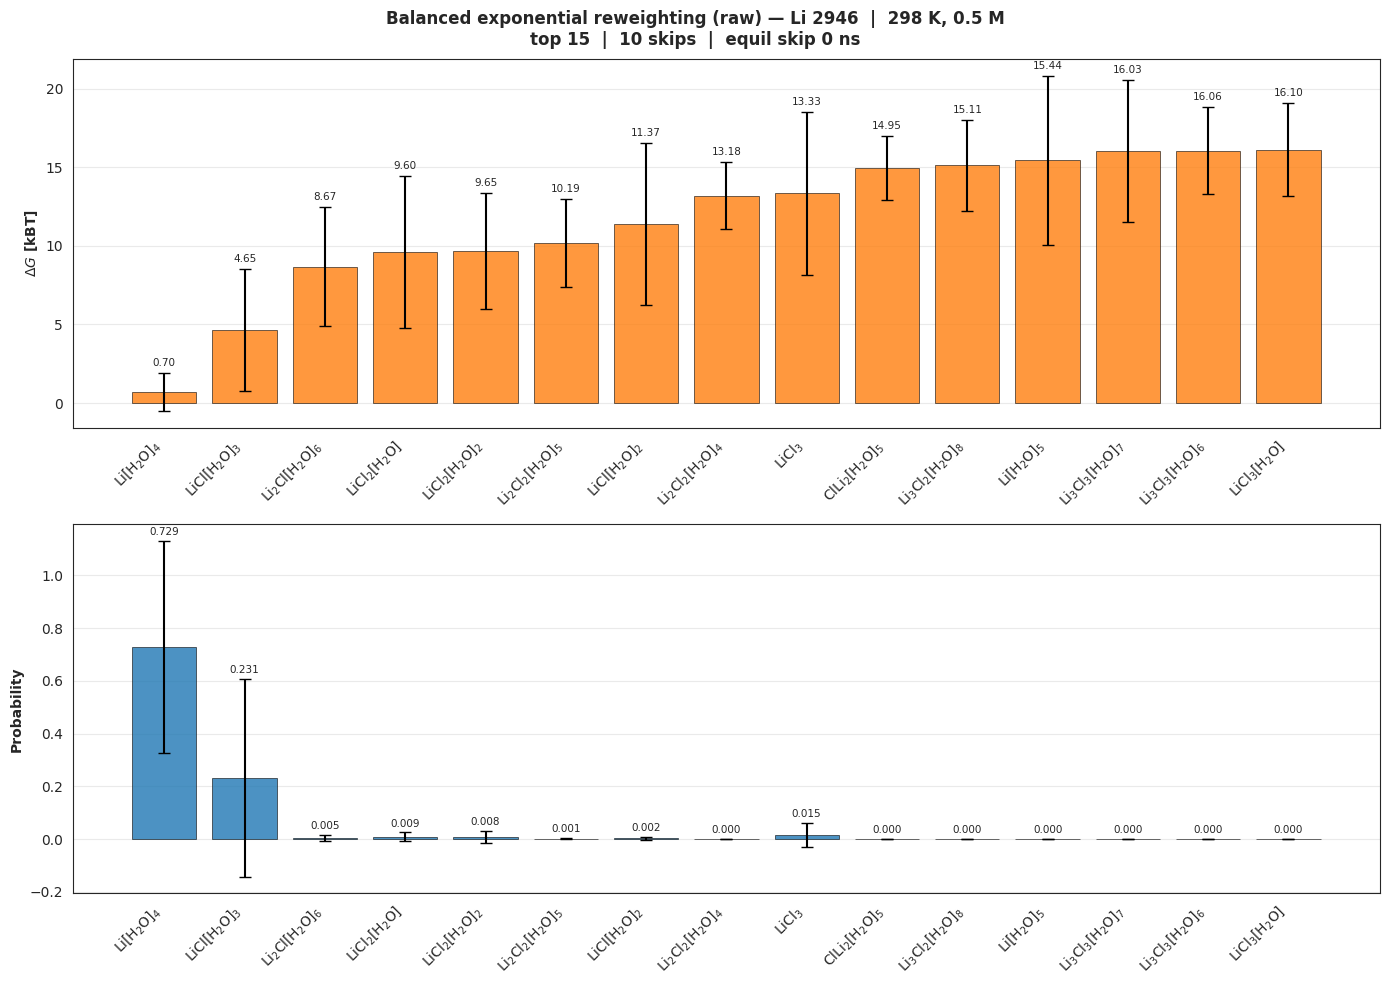

Saved stats.png


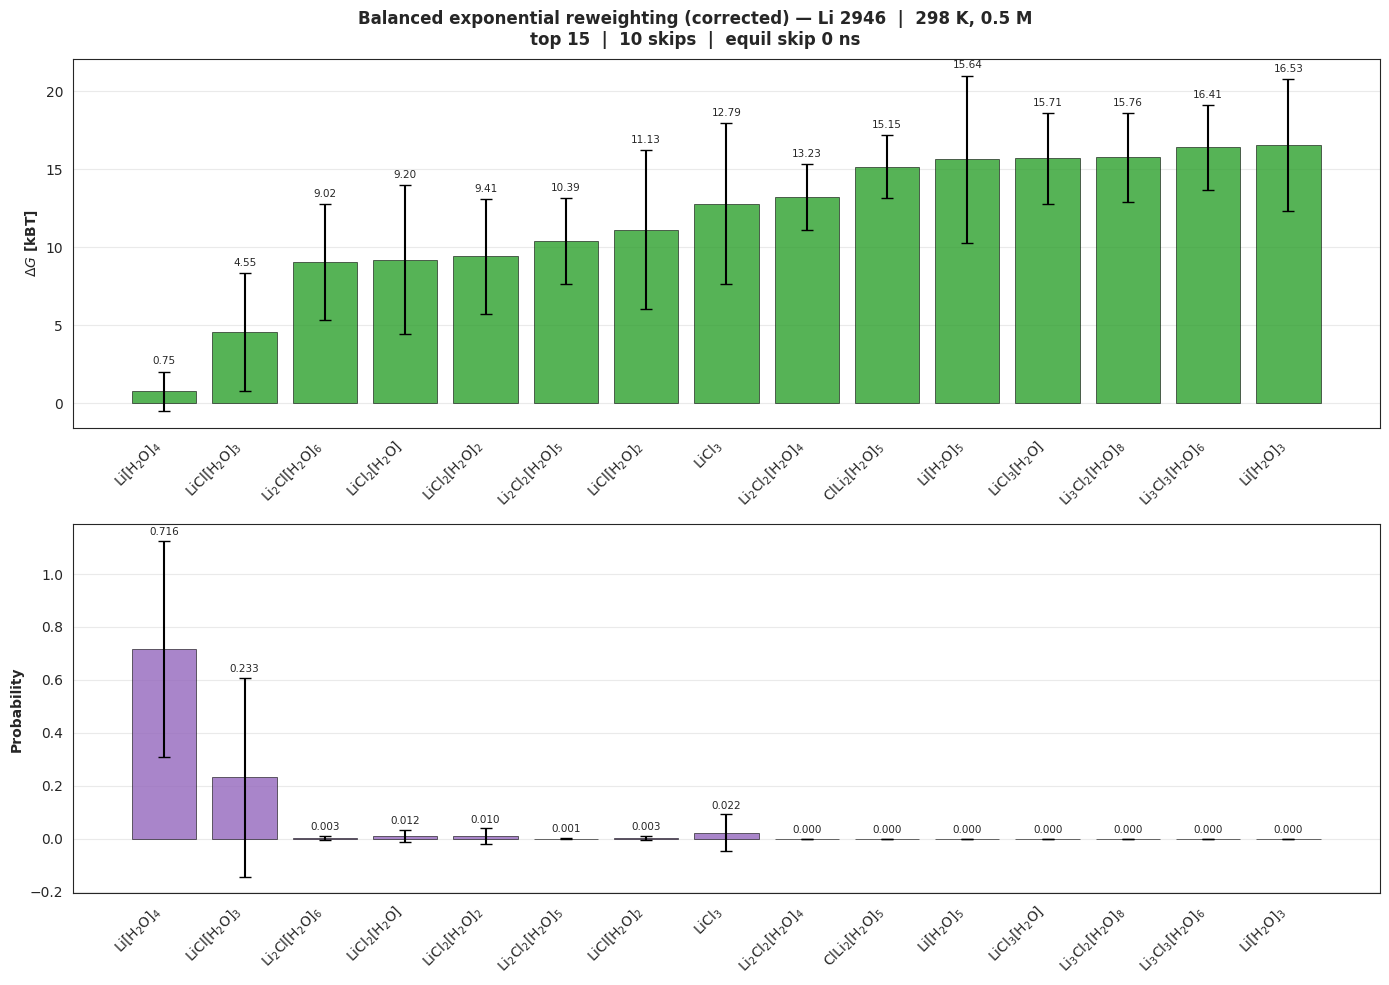

Saved stats_corrected.png


In [14]:
N_TOP = min(15, len(stats_df))
n_sk  = len(skip_results)

plot_specs = [
    ('raw',       stats_df,       'energy_mean',      'energy_std',
     'prob_mean',      'prob_std',      'tab:orange','tab:blue',  'stats.png'),
    ('corrected', stats_df_corr,  'energy_corr_mean', 'energy_corr_std',
     'prob_corr_mean', 'prob_corr_std',   'tab:green', 'tab:purple','stats_corrected.png'),
]

for lbl, stats, em, es, pm, ps, ce, cp, fname in plot_specs:
    top  = stats.head(N_TOP)
    x    = np.arange(N_TOP)
    xlabels = top['display_name'].tolist()
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    for ax, col_m, col_s, ylabel, color in [
        (axes[0], em, es, r'$\Delta G$ [kBT]', ce),
        (axes[1], pm, ps, 'Probability',        cp),
    ]:
        yerr  = top[col_s].fillna(0) if col_s and col_s in top.columns else None
        ax.bar(x, top[col_m], yerr=yerr, capsize=4, color=color,
               alpha=0.8, edgecolor='k', linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=10)
        ax.set_ylabel(ylabel, fontweight='bold')
        ax.grid(axis='y', alpha=0.4)
        s_vals = top[col_s].fillna(0) if col_s and col_s in top.columns else pd.Series([0]*N_TOP)
        for i, (m, s) in enumerate(zip(top[col_m], s_vals)):
            fmt = f'{m:.3f}' if 'prob' in col_m else f'{m:.2f}'
            ax.text(i, m + s + abs(max(top[col_m])) * 0.02, fmt,
                    ha='center', va='bottom', fontsize=7.5)
    plt.suptitle(
        f'Balanced exponential reweighting ({lbl}) — Li {LI_INDEX}  |  {T} K, {CONC} M\n'
        f'top {N_TOP}  |  {n_sk} skips  |  equil skip {EQUIL_NS:.0f} ns',
        fontsize=12, fontweight='bold')
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_PATH, fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')